In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import pandas
from tqdm import tqdm

# circuit quantization of a detuned BS

In [3]:
def dchi_H(drive_parameters, alpha):
    qdim = drive_parameters['N_q'] # qubit dimension
    rdim = drive_parameters['N_c'] # resonator dimension
    detuning = drive_parameters['detuning'] # qubit-resonator detuning
    gbs = drive_parameters['gbs']      # qubit-resonator coupling strength
    a_q = qt.tensor(qt.qeye(rdim), qt.destroy(qdim)) # qubit annihilation operator (resonator X qubit)
    a_r = qt.tensor(qt.destroy(rdim), qt.qeye(qdim)) # resonator annihilation operator (resonator X qubit)
    H0 = detuning * a_q.dag() * a_q + gbs * (a_q.dag() * a_r + a_q * a_r.dag()) # move to rotating frame where qubit and resonator rotate at same frequency of resonator frequency. Include Jaynes-Cummings interaction. Because both oscillators rotate at resonator frequency, JC interaction is time-independent.
    H0 += alpha/2 * a_q.dag() * a_q.dag() * a_q * a_q # add qubit anharmonicity term

    evals, evecs = H0.eigenstates() # get eigenvalues and eigenstates
    evals = evals-min(evals)  # shift ground state to 0 energy
    
    # sort evals and evecs from low to high first before sorting by excitation number
    idx_sort = np.argsort(evals) # indices that would sort evals
    evals = [evals[i] for i in idx_sort] # sort evals
    evecs = [evecs[i] for i in idx_sort] # sort evecs accordingly to match evals. one column list and each element is a Qobj state vector

    # sort eigenstates by number of resonator and qubit excitations, relabeled as a 2d array
    # calculate <n_r> and <n_q> and map it to the closest integer
    # evecs_sorted[n_r][n_q] gives the eigenstate with n_r resonator excitations and n_q qubit excitations
    # first index is resonator excitations, second index is qubit excitations
    evecs_sorted = [[None for _ in range(qdim)] for _ in range(rdim)]
    evals_sorted = [[None for _ in range(qdim)] for _ in range(rdim)] 

    override_numbers = [] # list of (n_r, n_q) pairs which have two possible assignments

    for i, evec in enumerate(evecs):
        n_r = round(qt.expect(a_r.dag() * a_r, evec).real)
        n_q = round(qt.expect(a_q.dag() * a_q, evec).real)
        if evecs_sorted[n_r][n_q] == None: # only assign if that state is not already assigned
            evecs_sorted[n_r][n_q] = evec
            evals_sorted[n_r][n_q] = evals[i]
        else:
            # this (n_r, n_q) pair has two possible assignments, store it for later resolution
            override_numbers.append((n_r, n_q, i))
    chis = evals_sorted[1][1]-evals_sorted[1][0]-evals_sorted[0][1]+evals_sorted[0][0]    
    chisp = evals_sorted[2][1]-evals_sorted[2][0]-evals_sorted[1][1]+evals_sorted[1][0] - chis
    dalpha = evals_sorted[2][0]-2*evals_sorted[1][0]+evals_sorted[0][0]    
    dalphap = evals_sorted[3][0]-2*evals_sorted[2][0]+evals_sorted[1][0] - dalpha

    chi_list = []
    chi_list_numbers = [] # list of (n_r, n_r-1) pairs for calculating chi_list
    for i in range(len(evals_sorted)-1):
        if evals_sorted[i+1][0] is not None and evals_sorted[i][0] is not None and evals_sorted[i+1][1] is not None and evals_sorted[i][1] is not None: # check if states exist
            chi_list.append(evals_sorted[i+1][1]-evals_sorted[i][1]-(evals_sorted[i+1][0]-evals_sorted[i][0]))
            chi_list_numbers.append((i+1,i)) # resonator excitation numbers used for this chi
    
    results = {'evals': evals_sorted, 'evecs': evecs_sorted, 'overrides': override_numbers, 'chi_list_numbers': chi_list_numbers, 'chi_list': chi_list}

    return results, chis, dalpha, dalphap, chisp

In [23]:
drive_parameters = {
    'N_q': 14,   
    'N_c': 18,
    'detuning': 164*2*np.pi,  # qubit-resonator detuning in angular frequency
    'gbs': 0.59*2*np.pi,       # qubit-resonator coupling strength in angular frequency
}
alpha = -168.4*2*np.pi  # qubit anharmonicity in MHz angular frequency
results, chis, dalpha, dalphap, chisp = dchi_H(drive_parameters, alpha)
print(f'Dispersive shift chi: {chis/(2*np.pi):.6f} MHz')
print(f'Dispersive shift chi prime: {chisp/(2*np.pi):.6f} MHz')
print(f'Dispersive shift chi list: {np.array(results['chi_list'])/(2*np.pi)} MHz')
print(f'Cavity alpha: {dalpha/(2*np.pi)*1e3:.6f} kHz')
print(f'Cavity alpha prime: {dalphap/(2*np.pi)*1e3:.6f} kHz')

Dispersive shift chi: 0.157016 MHz
Dispersive shift chi prime: -0.009105 MHz
Dispersive shift chi list: [0.15701646 0.14791153 0.1402784  0.13375861 0.12810519 0.12314169
 0.11873821 0.11479671 0.11124163 0.10801364 0.10506545 0.10235881
 0.09986242 0.09755038 0.09540105 0.09339618 0.06259471] MHz
Cavity alpha: -0.000058 kHz
Cavity alpha prime: 0.000000 kHz


In [14]:
drive_parameters = {
    'N_q': 5,   
    'N_c': 10,
    'detuning': 164*2*np.pi,  # qubit-resonator detuning
    'gbs': 0.59*2*np.pi,       # qubit-resonator coupling strength
}
alpha = -168.4*2*np.pi  # qubit anharmonicity in MHz
detuning_list = np.linspace(140.5, 180.5, 101)*2*np.pi
dchi, dalpha_arr, dalphap_arr, dchip = [], [], [], []

for detuning in tqdm(detuning_list):
    drive_parameters['detuning'] = detuning
    results, chis, dalpha, dalphap, chisp = dchi_H(drive_parameters, alpha)
    dchi.append(chis/(2*np.pi))
    dalpha_arr.append(dalpha/(2*np.pi)*1e3)
    dalphap_arr.append(dalphap/(2*np.pi)*1e3)
    dchip.append(chisp/(2*np.pi))

100%|██████████| 101/101 [00:00<00:00, 689.63it/s]


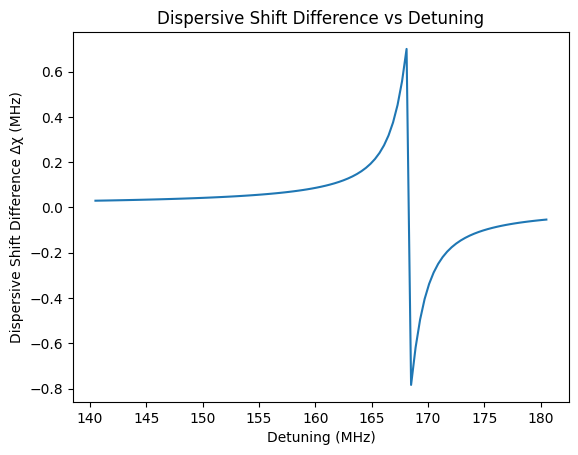

In [15]:
plt.plot(detuning_list/(2*np.pi), dchi)
plt.xlabel('Detuning (MHz)')
plt.ylabel('Dispersive Shift Difference Δχ (MHz)')
plt.title('Dispersive Shift Difference vs Detuning')
# plt.ylim(-4, 4)
plt.show()  

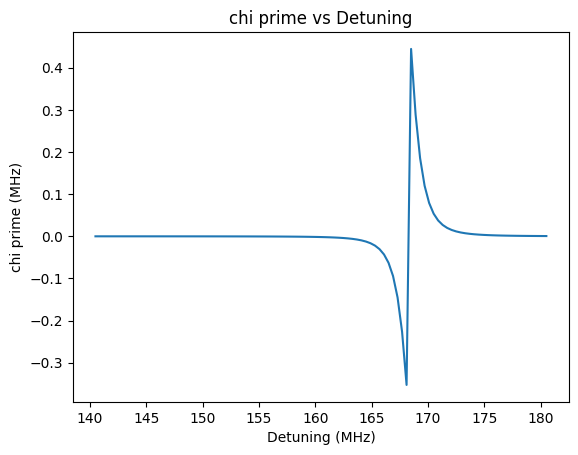

In [16]:
plt.plot(detuning_list/(2*np.pi), dchip)
plt.xlabel('Detuning (MHz)')
plt.ylabel('chi prime (MHz)')
plt.title('chi prime vs Detuning')
plt.tight_layout
plt.show()  

In [7]:
"""
Option A (simple + dims-safe):

1) Optimize a controlled-parity mapping gate using ONLY cavity Fock levels n=0..5
   by setting Nc = 6 in the optimization Hilbert space.

2) Reuse the SAME optimized detuning pulse Δ(t) in a BIGGER cavity Hilbert space
   (Nc_big, e.g. 18) to check:
     - leakage out of the n<=5 subspace
     - conditional gate fidelity on the n<=5 subspace

Important QuTiP detail:
  Always build identities/operators with CONSISTENT tensor dims.
  Use qt.tensor(qeye(Nc), qeye(Nq)) rather than qeye(Nc*Nq).
"""

import numpy as np
import qutip as qt
from qutip_qtrl.pulseoptim import optimize_pulse_unitary

# =========================
# 0) Choose dimensions / parameters
# =========================

Nc = 6          # optimization cavity dim: levels 0...Nc-1 only
Nc_big = 18     # validation cavity dim: includes higher levels
Nq = 3          # transmon truncation (>=2). 3 allows some |2> leakage physics.
Nq_big = 8      # validation qubit dim: includes higher levels

g = 1.0 * 2*np.pi        # coupling (angular units)
alpha = -160.0 * 2*np.pi # transmon anharmonicity (angular units)

n_ts = 120       # number of GRAPE time slots
T = 2.0          # total gate time (µs if frequencies are in 2π MHz)

det_min = -300.0 * 2*np.pi
det_max = 300.0 * 2*np.pi

# =========================
# 1) Helper constructors
# =========================

def sigmaz_01(Nq: int) -> qt.Qobj:
    """
    σz acting on the computational transmon subspace {|0>,|1>},
    embedded in an Nq-level truncation:
      diag = [+1, -1, 0, 0, ...]
    """
    d = np.zeros(Nq, dtype=float)
    d[0] = +1.0
    d[1] = -1.0
    return qt.Qobj(np.diag(d))

def make_H(Nc: int, Nq: int, g: float, alpha: float):
    """
    Build drift and control Hamiltonians for detuning control:

      H(t) = H_d + Δ(t) * H_c

    where:
      - H_d contains JC exchange + transmon Kerr anharmonicity
      - H_c is the transmon number operator n_q = a_q† a_q
    Tensor order: cavity ⊗ transmon.

    Returns:
      H_d, H_c
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    H_c = n_q
    return H_d, H_c

def target_controlled_parity(Nc: int, Nq: int) -> qt.Qobj:
    """
    Controlled-parity mapping gate (Ramsey-style):

      U_target = exp( -i (π/2) * n_cavity * σz^(01) )

    n_cavity acts on cavity, σz^(01) acts on transmon |0>,|1>.
    """
    n_r = qt.tensor(qt.num(Nc), qt.qeye(Nq))
    sz = qt.tensor(qt.qeye(Nc), sigmaz_01(Nq))
    return (-1j * (np.pi/2.0) * (n_r * sz)).expm()


# =========================
# 2) Optimize in LOW space (Nc = 6)
# =========================

H_d, H_c = make_H(Nc, Nq, g, alpha)

# IMPORTANT: dims-safe identity (cavity ⊗ transmon), not qeye(Nc*Nq)
U0 = qt.tensor(qt.qeye(Nc), qt.qeye(Nq))

U_targ = target_controlled_parity(Nc, Nq)

# In your qutip-qtrl version, bounds must be scalars for single control
res = optimize_pulse_unitary(
    H_d, [H_c], U0, U_targ,
    num_tslots=n_ts,
    evo_time=T,
    amp_lbound=[det_min],
    amp_ubound=[det_max],
    fid_err_targ=1e-4,
    max_iter=300,
    phase_option="PSU",
    init_pulse_type="RND",
    log_level=20
)

amps = res.final_amps[:, 0]  # (n_ts,)
print("LOW-space fid_err:", res.fid_err)

# =========================
# 3) Build realized unitary in BIG space using the SAME pulse
# =========================

H_dB, H_cB = make_H(Nc_big, Nq_big, g, alpha)
U_targB = target_controlled_parity(Nc_big, Nq_big)

# dims-safe identity in big space
U_big = qt.tensor(qt.qeye(Nc_big), qt.qeye(Nq_big)) # will be total propagator in BIG space
dt = T / n_ts
for k in range(n_ts):
    # Hamiltonian in this timeslot (piecewise-constant)
    Hk = H_dB + amps[k] * H_cB

    # One-step propagator exp(-i Hk dt)
    U_step = (-1j * Hk * dt).expm()

    # Time-ordered product: left-multiply
    U_big = U_step * U_big


# =========================
# 4) Evaluate leakage + conditional fidelity on the subspace (n<=5, qubit |0,1|)
# =========================

# Build indices for the low subspace inside the BIG Hilbert space.
# Flattened basis index for |n_cav>⊗|q> is: n*Nq + q (because tensor order is cavity ⊗ transmon).
idx = []
for n in range(Nc):          # cavity n = 0..Nc - 1
    for q in (0, 1):        # qubit levels |0>,|1>
        idx.append(n * Nq + q)

# Extract the low block from U_big and U_targB
U = U_big.full()
Ut = U_targB.full()

Ueff = U[np.ix_(idx, idx)]
Uteff = Ut[np.ix_(idx, idx)]
d = len(idx)  # subspace dimension

# (a) Survival and leakage
# survival = (1/d) Tr(Ueff† Ueff); leakage = 1 - survival
survival = (np.trace(Ueff.conj().T @ Ueff).real) / d
leakage = 1.0 - survival

# (b) Conditional fidelity:
# If leakage exists, Ueff is not unitary. Extract the closest unitary part via polar decomposition (SVD).
V, s, Wdag = np.linalg.svd(Ueff)
Uclosest = V @ Wdag

# Average gate fidelity between two unitaries (dimension d):
# F_avg = (|Tr(U_target† U)|^2 + d) / (d(d+1))
tr = np.trace(Uteff.conj().T @ Uclosest)
F_avg = (abs(tr)**2 + d) / (d * (d + 1))

print("\n--- BIG-space validation (care only about n<=5) ---")
print("subspace dim d      :", d)
print("survival (stay n<=5):", survival)
print("leakage (to n>=6)   :", leakage)
print("conditional F_avg   :", F_avg)

INFO:qutip_qtrl.dynamics:Setting memory optimisations for level 0
INFO:qutip_qtrl.dynamics:Internal operator data type choosen to be <class 'numpy.ndarray'>
INFO:qutip_qtrl.dynamics:phased dynamics generator caching True
INFO:qutip_qtrl.dynamics:propagator gradient caching True
INFO:qutip_qtrl.dynamics:eigenvector adjoint caching True
INFO:qutip_qtrl.dynamics:use sparse eigen decomp False
INFO:qutip_qtrl.pulseoptim:System configuration:
Drift Hamiltonian:
Quantum object: dims=[[6, 3], [6, 3]], shape=(18, 18), type='oper', dtype=Dia, isherm=True
Qobj data =
[[    0.             0.             0.             0.
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.             0.        ]
 [    0.             0.             0.             6.28318531
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.          

LOW-space fid_err: 0.135519744906894

--- BIG-space validation (care only about n<=5) ---
subspace dim d      : 12
survival (stay n<=5): 0.9999462547323984
leakage (to n>=6)   : 5.3745267601601476e-05
conditional F_avg   : 0.9535670996973735


In [10]:
"""
Optimal control where the *optimized object* is the parity-measurement Kraus/POVM,
NOT a unitary gate fidelity.

We assume:
  - Tensor order is cavity ⊗ transmon (as in qt.tensor(cavity_op, qubit_op)).
  - Prepare ancilla in |+x> (in the {|0>,|1>} subspace),
  - Apply a controlled interaction U(T) generated by H(t),
  - Measure ancilla in X basis -> outcomes +/-.
  - Kraus operators on the CAVITY are:
        M_± = <±x| U(T) |+x>
    (partial inner product over the ancilla)

What we optimize:
  The measurement (POVM elements):
        E_± = M_±† M_±
  should approximate parity projectors on the cared cavity subspace n < Nr:
        E_+ ≈ P_even,   E_- ≈ P_odd
  and we also enforce completeness on that subspace:
        E_+ + E_- ≈ I
  (This strongly penalizes ancilla leakage into unmeasured transmon levels.)

Why POVM objective?
  It's exactly "what matters for measuring parity" (outcome probabilities),
  and is much easier to satisfy than forcing M_± themselves to be projectors.

You can later add a "Kraus-as-projector" term if desired (see bottom).
"""

import numpy as np
import qutip as qt
from scipy.linalg import expm
from scipy.optimize import minimize

# =========================
# 0) USER SETTINGS
# =========================
Nc_big = 18      # simulate cavity with many levels (physics/leakage routes exist)
Nq     = 3       # simulate transmon with some leakage levels (>=2)
Nr     = 6       # we CARE about cavity Fock levels n=0..Nr-1 (e.g. 0..5)

n_ts = 60        # piecewise-constant time slices (control variables)
T    = 2.0       # total gate time (units consistent w/ Hamiltonian)
dt   = T / n_ts

# detuning bounds (angular units)
det_min =  50.0 * 2*np.pi
det_max = 300.0 * 2*np.pi

# Hamiltonian parameters (angular units)
g     = 1.0 * 2*np.pi
alpha = -160.0 * 2*np.pi

# optimization settings
MAXITER = 250

# =========================
# 1) BUILD HAMILTONIANS H(t) = H_d + Δ(t) H_c
# =========================
def build_H(Nc, Nq, g, alpha):
    """
    Build drift + control for detuning modulation.
    Tensor order: cavity ⊗ transmon.
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    # Drift: exchange coupling + transmon Kerr
    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    # Control Hamiltonian: detuning multiplies n_q
    H_c = n_q
    return H_d, H_c

H_d, H_c = build_H(Nc_big, Nq, g, alpha)

# Dense numpy versions for fast expm stepping
H_d_mat = H_d.full()
H_c_mat = H_c.full()

dim = Nc_big * Nq

# =========================
# 2) DEFINE PARITY PROJECTORS ON THE CARED CAVITY SUBSPACE
# =========================
P_even = np.diag([1.0 if (n % 2 == 0) else 0.0 for n in range(Nr)]).astype(complex)
P_odd  = np.eye(Nr, dtype=complex) - P_even
I_Nr   = np.eye(Nr, dtype=complex)

# =========================
# 3) ANCILLA STATES |+x>, |±x> EMBEDDED IN Nq
# =========================
# We assume ancilla computational states are |0>,|1>.
# Embed X-basis vectors in Nq by putting zeros in higher levels.
plus_x  = np.zeros(Nq, dtype=complex)
plus_x[0] = 1/np.sqrt(2)
plus_x[1] = 1/np.sqrt(2)

mplus_x  = plus_x.copy()
mminus_x = np.zeros(Nq, dtype=complex)
mminus_x[0] =  1/np.sqrt(2)
mminus_x[1] = -1/np.sqrt(2)

# =========================
# 4) PROPAGATION: U(T) FOR A PIECEWISE-CONSTANT Δ(t)
# =========================
def propagator_from_amps(amps):
    """
    amps: length n_ts array of detunings Δ_k per timeslot.
    Returns full unitary U(T) as dim x dim dense numpy array.
    """
    U = np.eye(dim, dtype=complex)
    for k in range(n_ts):
        Hk = H_d_mat + amps[k] * H_c_mat
        Ustep = expm(-1j * Hk * dt)
        U = Ustep @ U  # time-ordered product
    return U

# =========================
# 5) KRAUS OPERATORS: M_± = <±x| U |+x>
# =========================
def kraus_from_U(U, Nr):
    """
    Compute cavity Kraus operators for +/- X measurement.

    Tensor order cavity ⊗ transmon implies the flattened index mapping:
        |n, q> -> i = n*Nq + q
    Therefore, the block that maps transmon q_in -> q_out on the cavity is:
        U_block[q_out, q_in] = U[q_out::Nq, q_in::Nq]  (shape Nc_big x Nc_big)

    Then:
        M_m = sum_{q_out,q_in} <m|q_out> * U_block[q_out,q_in] * <q_in|+x>
    Restrict cavity to n < Nr by slicing [:Nr, :Nr].
    """
    def Ublock(q_out, q_in):
        return U[q_out::Nq, q_in::Nq]  # (Nc_big, Nc_big)

    def kraus_for(mvec):
        M = np.zeros((Nr, Nr), dtype=complex)
        for q_out in range(Nq):
            if mvec[q_out] == 0:
                continue
            for q_in in range(Nq):
                if plus_x[q_in] == 0:
                    continue
                B = Ublock(q_out, q_in)[:Nr, :Nr]
                # <m|q_out> = conj(mvec[q_out]), <q_in|+x> = plus_x[q_in]
                M += np.conj(mvec[q_out]) * B * plus_x[q_in]
        return M

    return kraus_for(mplus_x), kraus_for(mminus_x)

# =========================
# 6) COST TERMS (POVM-based parity measurement)
# =========================
def povm_terms_from_kraus(Mp, Mm):
    """
    POVM elements on cavity subspace:
        E± = M±† M±
    """
    Ep = Mp.conj().T @ Mp
    Em = Mm.conj().T @ Mm
    return Ep, Em

def cost_terms(amps):
    """
    Return a dict of term breakdown so we can debug what limits performance.
    """
    U = propagator_from_amps(amps)
    Mp, Mm = kraus_from_U(U, Nr=Nr)
    Ep, Em = povm_terms_from_kraus(Mp, Mm)

    # (1) parity correctness of the POVM elements
    c_povm = (np.linalg.norm(Ep - P_even, ord="fro")**2
            + np.linalg.norm(Em - P_odd,  ord="fro")**2)

    # (2) completeness on cared subspace (penalizes ancilla leakage to unmeasured levels)
    c_comp = np.linalg.norm((Ep + Em) - I_Nr, ord="fro")**2

    # Optional diagnostics:
    # "how projective" are the POVM elements?
    c_idemE = (np.linalg.norm(Ep@Ep - Ep, ord="fro")**2
             + np.linalg.norm(Em@Em - Em, ord="fro")**2)

    # "how orthogonal" are they?
    c_orthE = (np.linalg.norm(Ep@Em, ord="fro")**2
             + np.linalg.norm(Em@Ep, ord="fro")**2)

    return {
        "c_povm": c_povm,
        "c_comp": c_comp,
        "c_idemE": c_idemE,
        "c_orthE": c_orthE,
    }

# Weights (tune these)
W_POVM = 1.0
W_COMP = 10.0   # usually needs to be strong if Nq>2
W_IDEM = 0.1
W_ORTH = 0.1

def cost(amps):
    # hard bound safety (optimizer also enforces bounds, but this protects line-search calls)
    if np.any(amps < det_min) or np.any(amps > det_max):
        return 1e9
    terms = cost_terms(amps)
    return (W_POVM*terms["c_povm"]
          + W_COMP*terms["c_comp"]
          + W_IDEM*terms["c_idemE"]
          + W_ORTH*terms["c_orthE"])

# =========================
# 7) OPTIMIZE (L-BFGS-B)
# =========================
amps0 = np.full(n_ts, 0.5*(det_min + det_max), dtype=float)
bounds = [(det_min, det_max)] * n_ts

print("\nRUNNING L-BFGS-B (POVM parity objective)\n")

res = minimize(
    cost,
    amps0,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": MAXITER, "disp": True}
)

amps_opt = res.x
print("\nOptimization success:", res.success)
print("Message:", res.message)
print("Final total cost:", res.fun)

# =========================
# 8) REPORT BREAKDOWN + FINAL OPERATORS
# =========================
final_terms = cost_terms(amps_opt)
print("\n--- TERM BREAKDOWN ---")
for k, v in final_terms.items():
    print(f"{k:>10s} : {v:.6e}")

# Compute final Kraus/POVM to inspect
U_final = propagator_from_amps(amps_opt)
Mp, Mm = kraus_from_U(U_final, Nr=Nr)
Ep, Em = povm_terms_from_kraus(Mp, Mm)

print("\n--- QUICK CHECKS (POVM) ---")
print("||Ep - P_even||_F^2 :", np.linalg.norm(Ep - P_even, ord="fro")**2)
print("||Em - P_odd ||_F^2 :", np.linalg.norm(Em - P_odd,  ord="fro")**2)
print("||Ep+Em - I||_F^2   :", np.linalg.norm((Ep+Em) - I_Nr, ord="fro")**2)

# Optional: also see how close the KRAUS operators themselves are to projectors (stronger condition).
# This is NOT required for a correct parity measurement, but you can inspect it:
print("\n--- OPTIONAL (Kraus projectiveness diagnostics) ---")
print("||Mp^2 - Mp||_F^2   :", np.linalg.norm(Mp@Mp - Mp, ord="fro")**2)
print("||Mm^2 - Mm||_F^2   :", np.linalg.norm(Mm@Mm - Mm, ord="fro")**2)
print("||Mp Mm||_F^2       :", np.linalg.norm(Mp@Mm, ord="fro")**2)



RUNNING L-BFGS-B (POVM parity objective)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           60     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.13728D+00    |proj g|=  4.11918D-02

At iterate    1    f=  4.04485D+00    |proj g|=  4.19215D-02
  ys=-1.271E-03  -gs= 9.178E-02 BFGS update SKIPPED

At iterate    2    f=  3.10981D+00    |proj g|=  6.14293D-03

At iterate    3    f=  3.10631D+00    |proj g|=  2.67962D-03

At iterate    4    f=  3.08884D+00    |proj g|=  2.23228D-03

At iterate    5    f=  3.04749D+00    |proj g|=  5.90778D-04

At iterate    6    f=  3.04165D+00    |proj g|=  2.94257D-04

At iterate    7    f=  3.04073D+00    |proj g|=  4.45027D-04

At iterate    8    f=  3.03968D+00    |proj g|=  6.44158D-04

At iterate    9    f=  3.03670D+00    |proj g|=  6.73113D-04

At iterate   10    f=  3.03516D+00    |proj g|=  8.86145D-04

At iterate   11    f=  3.03272D+00    |proj g|=  9.5053

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (101,) and (1,)

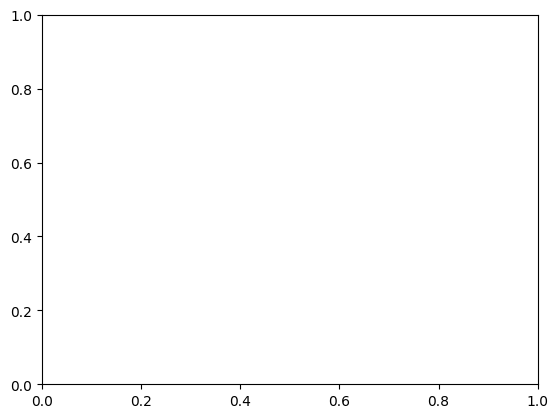

In [8]:
plt.plot(detuning_list/(2*np.pi), dalpha)
plt.xlabel('Detuning (MHz)')
plt.ylabel('alpha (kHz)')
plt.title('alpha vs Detuning')
# plt.ylim(-0.2, 0.2)
plt.show()  

## 2D scan, showing dchi, dchi', Kerr, Kerr'

In [237]:
drive_parameters = {
    'N_q': 8,   
    'N_c': 14,
    'detuning': -4.0*2*np.pi,  # qubit-resonator detuning
    'gbs': 2.0*2*np.pi,       # qubit-resonator coupling strength
}
alpha = -160.0*2*np.pi  # qubit anharmonicity in MHz
detuning_list1 = np.linspace(-30, 30, 70)*2*np.pi
detuning_list2 = np.linspace(120.5, 180.5, 70)*2*np.pi
gbs_list = np.linspace(0.0, 3.0, 31)*2*np.pi
dchi1, dalpha1, dalphap1, dchip1 = [], [], [], []
dchi2, dalpha2, dalphap2, dchip2 = [], [], [], []

for detuning in tqdm(detuning_list1):
    dchi_row, dalpha_row, dalphap_row, dchip_row = [], [], [], []
    for gbs in gbs_list:
        drive_parameters['detuning'] = detuning
        drive_parameters['gbs'] = gbs
        _, chis, dalpha, dalphap, chisp = dchi_H(drive_parameters, alpha)
        dchi_row.append(chis/(2*np.pi))
        dalpha_row.append(dalpha/(2*np.pi)*1e3)
        dalphap_row.append(dalphap/(2*np.pi)*1e3)
        dchip_row.append(chisp/(2*np.pi))
    dchi1.append(dchi_row)
    dalpha1.append(dalpha_row)
    dalphap1.append(dalphap_row)
    dchip1.append(dchip_row)

for detuning in tqdm(detuning_list2):
    dchi_row, dalpha_row, dalphap_row, dchip_row = [], [], [], []
    for gbs in gbs_list:
        drive_parameters['detuning'] = detuning
        drive_parameters['gbs'] = gbs
        _, chis, dalpha, dalphap, chisp = dchi_H(drive_parameters, alpha)
        dchi_row.append(chis/(2*np.pi))
        dalpha_row.append(dalpha/(2*np.pi)*1e3)
        dalphap_row.append(dalphap/(2*np.pi)*1e3)
        dchip_row.append(chisp/(2*np.pi))
    dchi2.append(dchi_row)
    dalpha2.append(dalpha_row)
    dalphap2.append(dalphap_row)
    dchip2.append(dchip_row)


100%|██████████| 70/70 [00:27<00:00,  2.56it/s]


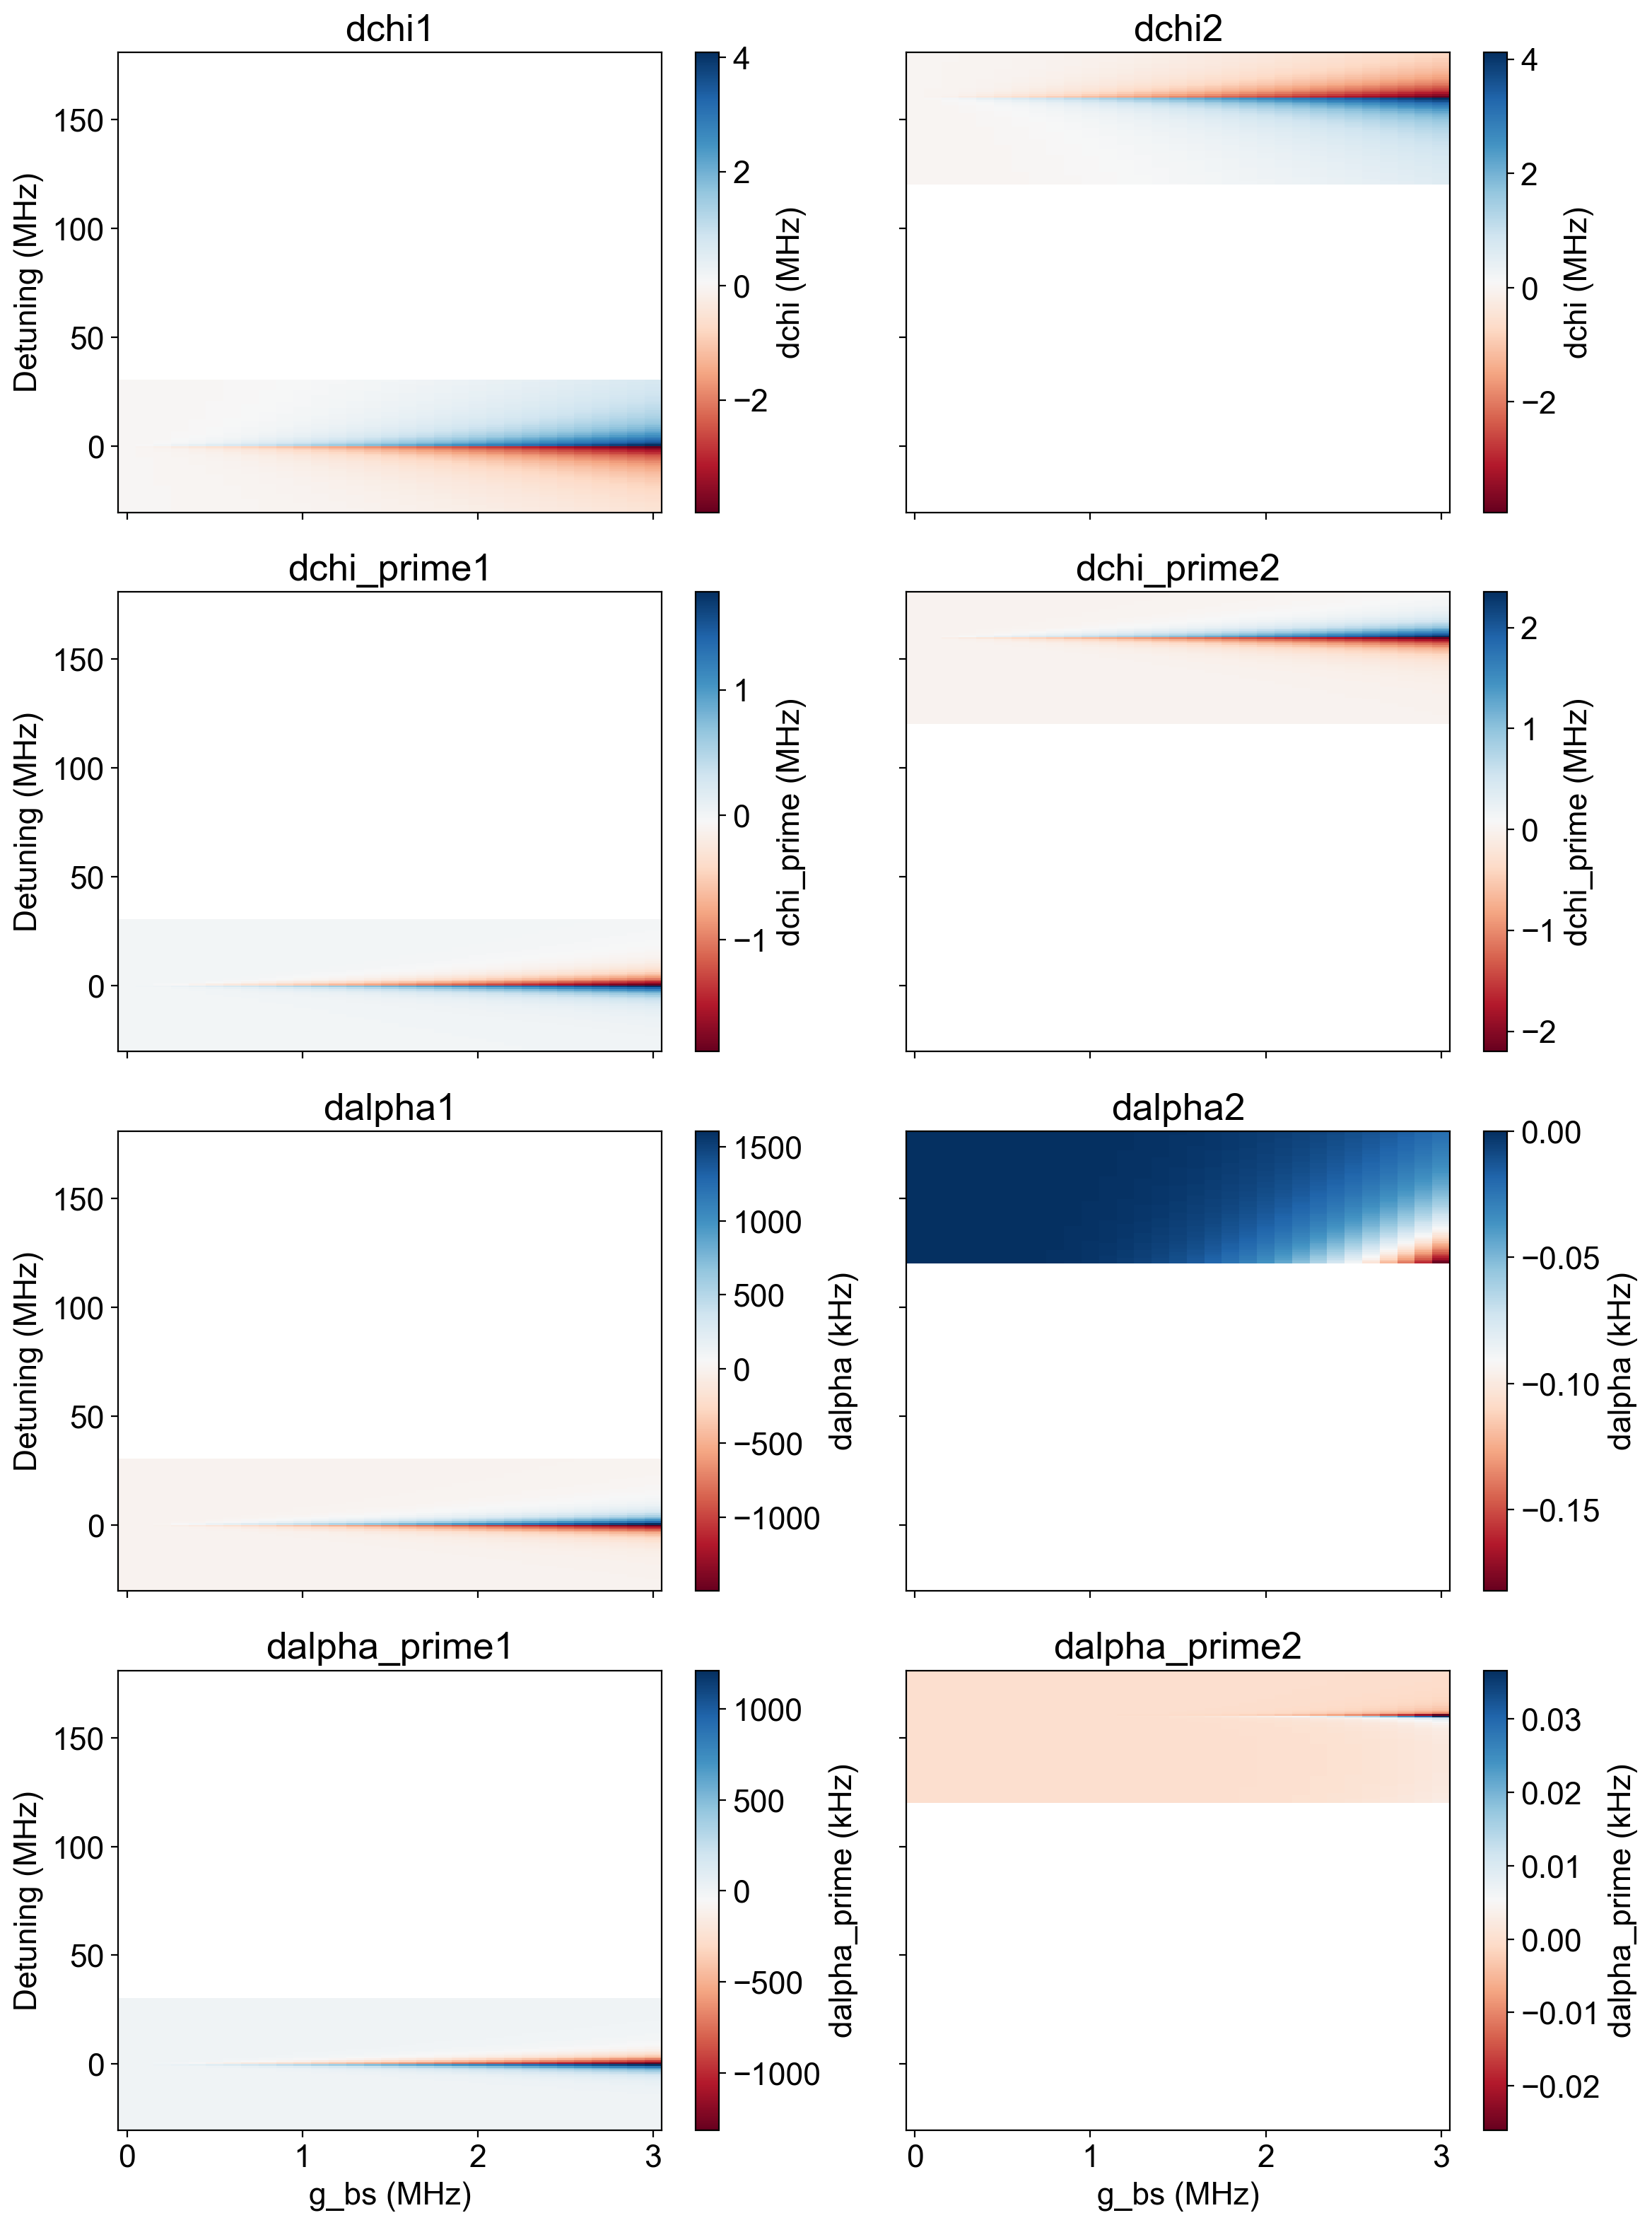

In [247]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=True, sharey=True)

# --- Row 1: dchi ---
pcm = axes[0, 0].pcolormesh(gbs_list/(2*np.pi), detuning_list1/(2*np.pi), dchi1,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[0, 0], label='dchi (MHz)')
axes[0, 0].set_title("dchi1")
axes[0, 0].set_ylabel("Detuning (MHz)")

pcm = axes[0, 1].pcolormesh(gbs_list/(2*np.pi), detuning_list2/(2*np.pi), dchi2,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[0, 1], label='dchi (MHz)')
axes[0, 1].set_title("dchi2")

# --- Row 2: dchi_prime ---
pcm = axes[1, 0].pcolormesh(gbs_list/(2*np.pi), detuning_list1/(2*np.pi), dchip1,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[1, 0], label='dchi_prime (MHz)')
axes[1, 0].set_title("dchi_prime1")
axes[1, 0].set_ylabel("Detuning (MHz)")

pcm = axes[1, 1].pcolormesh(gbs_list/(2*np.pi), detuning_list2/(2*np.pi), dchip2,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[1, 1], label='dchi_prime (MHz)')
axes[1, 1].set_title("dchi_prime2")

# --- Row 3: dalpha ---
pcm = axes[2, 0].pcolormesh(gbs_list/(2*np.pi), detuning_list1/(2*np.pi), dalpha1,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[2, 0], label='dalpha (kHz)')
axes[2, 0].set_title("dalpha1")
axes[2, 0].set_ylabel("Detuning (MHz)")

pcm = axes[2, 1].pcolormesh(gbs_list/(2*np.pi), detuning_list2/(2*np.pi), dalpha2,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[2, 1], label='dalpha (kHz)')
axes[2, 1].set_title("dalpha2")

# --- Row 4: dalpha_prime ---
pcm = axes[3, 0].pcolormesh(gbs_list/(2*np.pi), detuning_list1/(2*np.pi), dalphap1,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[3, 0], label='dalpha_prime (kHz)')
axes[3, 0].set_title("dalpha_prime1")
axes[3, 0].set_xlabel("g_bs (MHz)")
axes[3, 0].set_ylabel("Detuning (MHz)")

pcm = axes[3, 1].pcolormesh(gbs_list/(2*np.pi), detuning_list2/(2*np.pi), dalphap2,
                            shading='auto', cmap='RdBu')
fig.colorbar(pcm, ax=axes[3, 1], label='dalpha_prime (kHz)')
axes[3, 1].set_title("dalpha_prime2")
axes[3, 1].set_xlabel("g_bs (MHz)")

plt.tight_layout()
plt.show()


# analytical expression

In [161]:
def dchi_ala(drive_parameters, alpha):

    detuning = drive_parameters['detuning']
    gbs = drive_parameters['gbs']
    chis = -2*gbs**2*alpha/(detuning*(detuning-alpha))
    chis += 4*gbs**4*alpha*(alpha**2+2*detuning*(-alpha+detuning))/(detuning**3*(-alpha+detuning)**3)

    r_alpha = -2*gbs**4*alpha/(detuning**3*(2*detuning-alpha))      

    return chis, r_alpha

In [162]:
drive_parameters = {
    'N_q': 8,   
    'N_c': 12,
    'detuning': 20.0*2*np.pi,  # qubit-resonator detuning
    'gbs': 4.0*2*np.pi,       # qubit-resonator coupling strength
}
alpha = 160.0*2*np.pi  # qubit anharmonicity in MHz
dchi, dalpha = dchi_ala(drive_parameters, alpha)
print(f'Dispersive shift chi: {dchi/(2*np.pi):.6f} MHz')
print(f'Cavity alpha: {dalpha/(2*np.pi)*1e3:.6f} kHz')


Dispersive shift chi: 1.679300 MHz
Cavity alpha: 85.333333 kHz


In [131]:
drive_parameters = {
    'N_q': 8,   
    'N_c': 12,
    'detuning': -4.0*2*np.pi,  # qubit-resonator detuning
    'gbs': 2.0*2*np.pi,       # qubit-resonator coupling strength
}
alpha = 160.0*2*np.pi  # qubit anharmonicity in MHz
detuning_list = np.linspace(-100, 200, 1001)*2*np.pi
dchis_ala = []
r_alpha_ala = []
for detuning in tqdm(detuning_list):
    drive_parameters['detuning'] = detuning
    dchi, dalpha = dchi_ala(drive_parameters, alpha)
    dchis_ala.append(dchi/(2*np.pi))
    r_alpha_ala.append(dalpha/(2*np.pi))

  0%|          | 0/1001 [00:00<?, ?it/s]C:\Users\Inline6\AppData\Local\Temp\ipykernel_177836\1128732152.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  r_alpha = -2*gbs**4*alpha/(detuning**3*(2*detuning-alpha))
100%|██████████| 1001/1001 [00:00<00:00, 500894.57it/s]


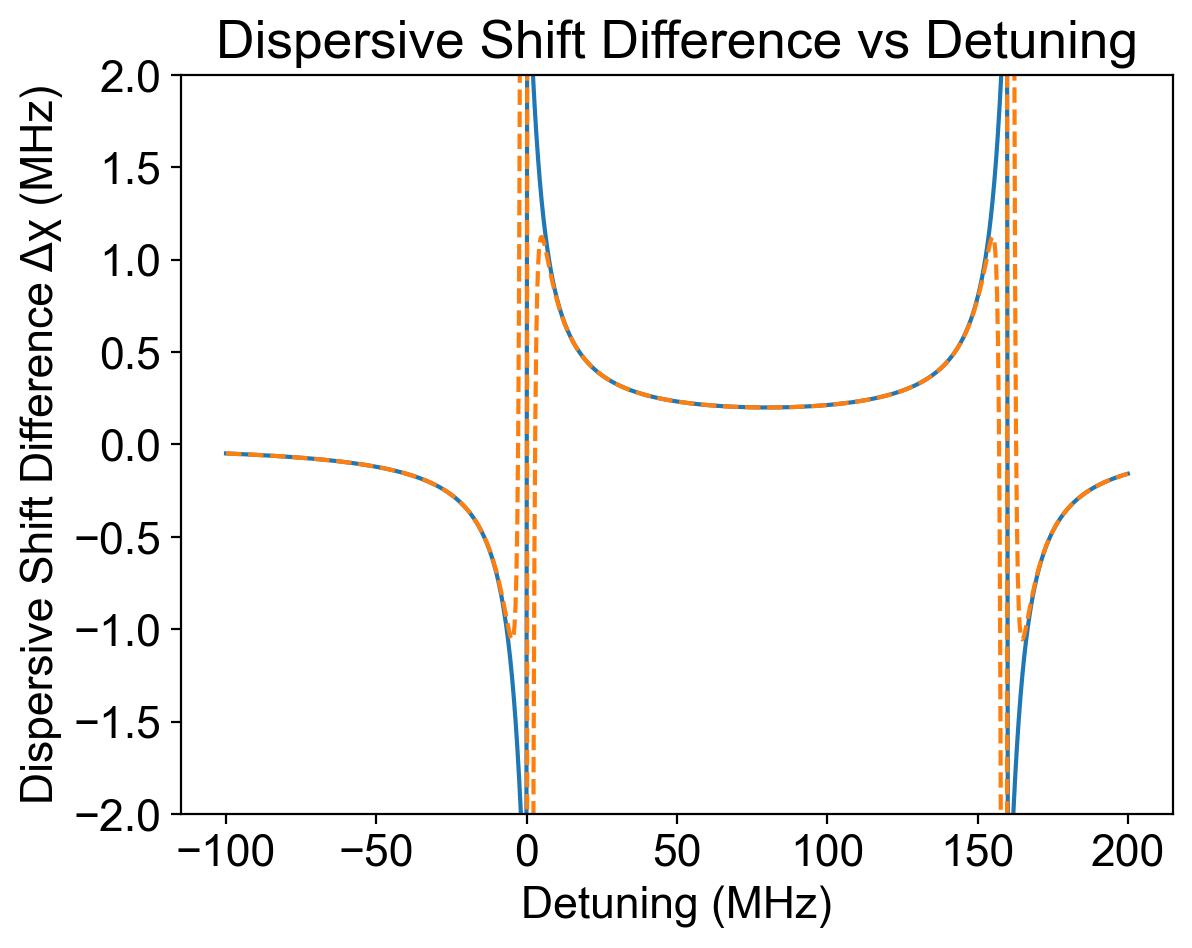

In [132]:
plt.plot(detuning_list/(2*np.pi), dchis, label='Numerical')
plt.plot(detuning_list/(2*np.pi), dchis_ala, '--', label='Analytical')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Dispersive Shift Difference Δχ (MHz)')
plt.title('Dispersive Shift Difference vs Detuning')
plt.ylim(-2, 2)
plt.show()  

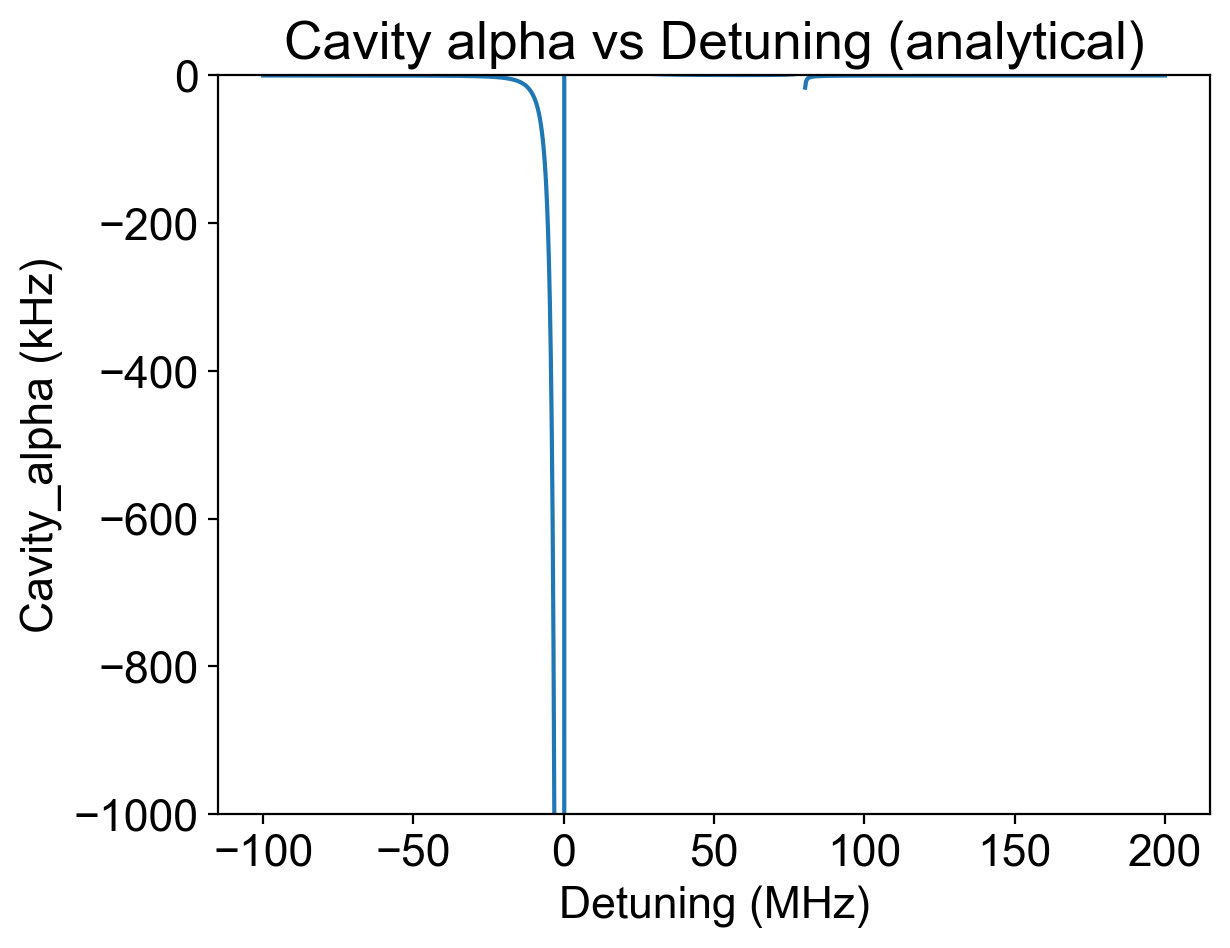

In [134]:
plt.plot(detuning_list/(2*np.pi), np.array(r_alpha_ala)*1e3)
plt.xlabel('Detuning (MHz)')
plt.ylabel('Cavity_alpha (kHz)')
plt.title('Cavity alpha vs Detuning (analytical)')
plt.ylim(-1000, 1)
plt.show()  

# Two detuned drives

In [119]:
def floquet_2drive_rotframe(drive_parameters, alpha):
    """
    Two-tone qubit–cavity Hamiltonian in the rotating frame you specified:

        H_rot(t) = delta1 * a_q† a_q + (alpha/2) n_q (n_q - 1)
                   + g1 (a_q† a_r + a_q a_r†)
                   + g2 (e^{i delta2 t} a_q† a_r + e^{-i delta2 t} a_r† a_q)

        delta1 = wd1 - (wq - wc)
        delta2 = wd2 - wd1 + delta1

    Returns:
        results: dict with
            'evals'      -> 2D list [n_r][n_q] of quasi-energies (shifted so min = 0)
            'evecs'      -> 2D list [n_r][n_q] of Floquet quasi-states (Qobj)
            'raw_eps'    -> 1D np.array of raw quasi-energies (shifted)
            'raw_states' -> list of Floquet modes (Qobj)
            'delta1'     -> delta1
            'delta2'     -> delta2
            'T'          -> Floquet period 2π/|delta2|
    """

    # --- unpack parameters ---
    qdim = drive_parameters['N_q']
    rdim = drive_parameters['N_c']

    wq   = drive_parameters['wq']
    wc   = drive_parameters['wc']
    g1   = drive_parameters['g1']
    g2   = drive_parameters['g2']
    wd1  = drive_parameters['wd1']
    wd2  = drive_parameters['wd2']

    # Your detunings
    delta1 = wd1 - (wq - wc)
    delta2 = wd2 - wd1 + delta1

    if np.isclose(delta2, 0.0):
        raise ValueError("delta2 ≈ 0: no remaining time dependence for tone 2.")

    # Single remaining Floquet frequency
    T = 2 * np.pi / np.abs(delta2)

    # Solver options (tune as needed)
    nsteps = drive_parameters.get('nsteps', 10000)
    rtol   = drive_parameters.get('rtol', 1e-10)
    atol   = drive_parameters.get('atol', 1e-12)

    # --- operators ---
    a_q = tensor(qt.qeye(rdim), qt.destroy(qdim))   # qubit mode
    a_r = tensor(qt.destroy(rdim), qt.qeye(qdim))   # cavity mode

    n_q = a_q.dag() * a_q

    # static part: delta1 n_q + alpha/2 n_q(n_q-1) + g1 (a_q† a_r + h.c.)
    H0 = (
        delta1 * n_q
        + alpha/2 * a_q.dag() * a_q.dag() * a_q * a_q
        + g1 * (a_q.dag() * a_r + a_q * a_r.dag())
    )

    O = a_q.dag() * a_r  # coupling operator for tone 2

    # --- time dependence for tone 2 only ---
    def exp_i_delta2_t(t, args):
        return np.exp(1j * args['delta2'] * t)

    def exp_minus_i_delta2_t(t, args):
        return np.exp(-1j * args['delta2'] * t)

    args = {'delta2': delta2}

    H = [
        H0,
        [g2 * O,       exp_i_delta2_t],
        [g2 * O.dag(), exp_minus_i_delta2_t],
    ]

    # --- Floquet calculation with better accuracy ---
    opts = qt.Options(nsteps=nsteps, rtol=rtol, atol=atol)

    # Propagator over one period T with high-accuracy options
    U = qt.propagator(H, T, [], args=args, options=opts)

    # Floquet modes using this propagator (QuTiP 5.1.x)
    floquet_states, floquet_eps = qt.floquet_modes(H, T, args=args, U=U)

    # floquet_eps -> real array, shift so ground energy = 0
    floquet_eps = np.real(np.array(floquet_eps))
    floquet_eps -= floquet_eps.min()

    dim = rdim * qdim
    if len(floquet_states) != dim:
        raise RuntimeError(
            f"Dimension mismatch: got {len(floquet_states)} Floquet states, expected {dim}"
        )

    # --- build bare |n_r, n_q> basis in this rotating frame ---
    bare_states = []
    index_to_nm = []
    for n_r_int in range(rdim):
        for n_q_int in range(qdim):
            bare_states.append(tensor(qt.basis(rdim, n_r_int), qt.basis(qdim, n_q_int)))
            index_to_nm.append((n_r_int, n_q_int))

    # --- overlaps between bare basis and Floquet modes ---
    overlap_matrix = np.zeros((dim, dim), dtype=float)
    for i, psi_nm in enumerate(bare_states):
        for k, phi_k in enumerate(floquet_states):
            amp = psi_nm.overlap(phi_k)   # complex scalar in QuTiP 5.x
            overlap_matrix[i, k] = np.abs(amp)**2

    # --- assign Floquet states to (n_r, n_q) via greedy matching ---
    evecs_sorted  = [[None for _ in range(qdim)] for _ in range(rdim)]
    evals_sorted  = [[None for _ in range(qdim)] for _ in range(rdim)]
    used_floquet_indices = set()

    for i in range(dim):
        n_r_int, n_q_int = index_to_nm[i]

        k_sorted = np.argsort(overlap_matrix[i, :])[::-1]
        k_best = None
        for k in k_sorted:
            if k not in used_floquet_indices:
                k_best = k
                break

        if k_best is None:
            raise RuntimeError("Could not find unique Floquet state for all bare states.")

        used_floquet_indices.add(k_best)

        evecs_sorted[n_r_int][n_q_int] = floquet_states[k_best]
        evals_sorted[n_r_int][n_q_int] = floquet_eps[k_best]

    results = {
        'evals': evals_sorted,
        'evecs': evecs_sorted,
        'raw_eps': floquet_eps,
        'raw_states': floquet_states,
        'delta1': delta1,
        'delta2': delta2,
        'T': T,
    }
    return results

def unwrap_ladder(E_list, Omega):
    """
    Unwrap a list of quasi-energies along one ladder so that
    successive levels differ by much less than Omega.
    Removes the modulo-Omega ambiguity of Floquet quasienergies.
    """
    E_list = np.array(E_list, dtype=float)
    unwrapped = [E_list[0]]
    for E in E_list[1:]:
        k = np.round((unwrapped[-1] - E) / Omega)
        unwrapped.append(E + k * Omega)
    return np.array(unwrapped)

In [124]:
# parameters in MHz
drive_parameters = {
    'N_q': 10,
    'N_c': 10,
    'wq': 4400 * 2*np.pi,      # MHz
    'wc': 5200 * 2*np.pi,      # MHz
    'g1': 1.0 * 2*np.pi,       # MHz
    'g2': 0.01 * 2*np.pi,      # MHz
    'wd1': -735.0 * 2*np.pi,    # MHz  (tone 1: reference frame)
    'wd2': -745.0 * 2*np.pi,    # MHz  (tone 2: residual time dependence)
    # numerical Floquet accuracy
    'nsteps': 100000,
    'rtol': 1e-10,
    'atol': 1e-12,
}
alpha = -160 * 2*np.pi       # MHz

# --- Floquet calculation & sorting in rotating frame ---
results = floquet_2drive_rotframe(drive_parameters, alpha)
evals_sorted = results['evals']
evecs_sorted = results['evecs']

# -------------------------
# Unwrap ladders & compute chi/alpha
# -------------------------
Omega = abs(results['delta2'])   # Floquet base frequency = |wd2 - wd1|

Nc_eff = min(8, len(evals_sorted))

# ladders: cavity n_r = 0..Nc_eff-1, qubit in |0>, |1>
E_q0 = [evals_sorted[n][0] for n in range(Nc_eff)]
E_q1 = [evals_sorted[n][1] for n in range(Nc_eff)]

E_q0_u = unwrap_ladder(E_q0, Omega)
E_q1_u = unwrap_ladder(E_q1, Omega)

# χ = (E_11 - E_10) - (E_01 - E_00)
chis = (E_q1_u[1] - E_q1_u[0]) - (E_q0_u[1] - E_q0_u[0])

# χ' = ((E_21 - E_20) - (E_11 - E_10)) - χ
chisp = (
    (E_q1_u[2] - E_q1_u[1])
    - (E_q0_u[2] - E_q0_u[1])
    - chis
)

# cavity Kerr α_c = E_20 - 2E_10 + E_00
dalpha = E_q0_u[2] - 2 * E_q0_u[1] + E_q0_u[0]

# α_c' = (E_30 - 2E_20 + E_10) - α_c
dalphap = (E_q0_u[3] - 2 * E_q0_u[2] + E_q0_u[1]) - dalpha

chi_list = []
max_n = min(8, Nc_eff - 1)
for i in range(max_n):
    chi_i = (
        (E_q1_u[i+1] - E_q1_u[i])
        - (E_q0_u[i+1] - E_q0_u[i])
    )
    chi_list.append(chi_i)

# -------------------------
# Print in your exact style
# -------------------------
print(f"Dispersive shift chi: {chis/(2*np.pi):.6f} MHz")
print(f"Dispersive shift chi prime: {chisp/(2*np.pi):.6f} MHz")
print(f"Dispersive shift chi list: {np.array(chi_list)/(2*np.pi)} MHz")
print(f"Cavity alpha: {dalpha/(2*np.pi)*1e3:.6f} kHz")
print(f"Cavity alpha prime: {dalphap/(2*np.pi)*1e3:.6f} kHz")

Dispersive shift chi: 0.051793 MHz
Dispersive shift chi prime: -0.000068 MHz
Dispersive shift chi list: [0.05179254 0.05172427 0.05165617 0.05158824 0.05152048 0.05145289
 0.05138547] MHz
Cavity alpha: 0.038778 kHz
Cavity alpha prime: -0.000093 kHz


## Compare with 1 drive

In [109]:
drive_parameters = {
    'N_q': 14,   
    'N_c': 18,
    'detuning': 150*2*np.pi,  # qubit-resonator detuning
    'gbs': 2.0*2*np.pi,       # qubit-resonator coupling strength
}
alpha = -160.0*2*np.pi  # qubit anharmonicity in MHz
results, chis, dalpha, dalphap, chisp, chi_list = dchi_H(drive_parameters, alpha)
print(f'Dispersive shift chi: {chis/(2*np.pi):.6f} MHz')
print(f'Dispersive shift chi prime: {chisp/(2*np.pi):.6f} MHz')
print(f'Dispersive shift chi list: {np.array(chi_list)/(2*np.pi)} MHz')
print(f'Cavity alpha: {dalpha/(2*np.pi)*1e3:.6f} kHz')
print(f'Cavity alpha prime: {dalphap/(2*np.pi)*1e3:.6f} kHz')

Dispersive shift chi: 0.794192 MHz
Dispersive shift chi prime: -0.080802 MHz
Dispersive shift chi list: [0.79419177 0.71338964 0.65477211 0.60972275 0.57369011 0.54401106
 0.51900896 0.49756829] MHz
Cavity alpha: -0.010824 kHz
Cavity alpha prime: 0.000185 kHz
